# Regresión cuantílica de la esperanza de vida

En este trabajo se analiza la relación entre `life_expectancy`, `income_index` y `schooling` mediante una regresión lineal de referencia y regresiones cuantílicas.

La pregunta central es si el efecto de los recursos económicos y la escolaridad es igual para todos los niveles de esperanza de vida o si cambia entre países con valores bajos, medios y altos. OLS responde sobre la esperanza de vida media condicionada a las variables explicativas; la regresión cuantílica permite estudiar la parte baja, central y alta de esa distribución.

La regresión lineal resume la media condicional:

$$E(Y_i \mid X_i)$$

La regresión cuantílica estima un cuantil condicional:

$$Q_Y(\tau \mid X_i)$$

donde $\tau \in (0,1)$. Así, $\tau=0.5$ representa la mediana, $\tau=0.1$ los países situados en la parte baja de la esperanza de vida condicionada y $\tau=0.95$ los situados en la parte alta. La comparación entre las pendientes $\beta_j(\tau)$ permite identificar heterogeneidad.

# Importante: 
Este ejemplo tiene como objetivo brindar una primera visión de la regresión cuantílica y mostrar cómo se comporta la relación entre la esperanza de vida y el índice de ingresos en diferentes partes de la distribución. No pretende ser un tratamiento definitivo de los datos faltantes.

## Preparación del entorno de R

Este bloque instala `pacman`, que se utiliza en la siguiente celda para cargar de forma conjunta las librerías del análisis. Normalmente solo es necesario ejecutarlo una vez por entorno de R.

In [1]:
install.packages("pacman")

Installing package into 'C:/Users/PERSONAL/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'pacman' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\PERSONAL\AppData\Local\Temp\RtmpSQ8fkg\downloaded_packages


## 1. Carga de paquetes

En este análisis se utilizan paquetes para importar, limpiar, modelar y visualizar los datos:

- **dplyr:** transformación y filtrado de datos.
- **janitor:** limpieza y estandarización de nombres de columnas.
- **ggplot2:** gráficos estadísticos.
- **quantreg:** estimación de regresiones cuantílicas mediante `rq()`.
- **sjPlot:** comparación visual de modelos.
- **plotly:** gráficos interactivos, incluidos los resultados de QQR.

El paquete central es **quantreg**, porque permite estimar cómo cambia la relación entre las variables explicativas y distintos puntos de la distribución de la esperanza de vida.

In [2]:
library(pacman)

p_load(
  dplyr,
  janitor,
  ggplot2,
  quantreg,
  sjPlot,
  plotly
)

In [3]:
library(ggplot2)
if(!require(reshape2)) install.packages("reshape2")
library(reshape2)

Cargando paquete requerido: reshape2



## 2. Importación del conjunto de datos

El archivo se encuentra en `data/raw/`. Como el cuaderno está dentro de `notebooks/`, se accede mediante `../data/raw/life_expectancy.csv`. La opción `na.strings = ""` convierte las celdas vacías en valores perdidos (`NA`), que luego serán tratados antes de estimar los modelos.

La salida `head(life_exp)` permite comprobar las primeras observaciones, los nombres originales de las variables y el tipo de información disponible.

In [4]:
life_exp <- read.csv(
  "../data/raw/life_expectancy.csv",
  na.strings = ""
)

head(life_exp)

,Country,Year,Status,Life.expectancy,Adult.Mortality,infant.deaths,Alcohol,percentage.expenditure,Hepatitis.B,Measles,⋯,Polio,Total.expenditure,Diphtheria,HIV.AIDS,GDP,Population,thinness..1.19.years,thinness.5.9.years,Income.composition.of.resources,Schooling
,<chr>,<int>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,⋯,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Afghanistan,2015,Developing,65.0,263,62,0.01,71.279624,65,1154,⋯,6,8.16,65,0.1,584.25921,33736494,17.2,17.3,0.479,10.1
2,Afghanistan,2014,Developing,59.9,271,64,0.01,73.523582,62,492,⋯,58,8.18,62,0.1,612.69651,327582,17.5,17.5,0.476,10.0
3,Afghanistan,2013,Developing,59.9,268,66,0.01,73.219243,64,430,⋯,62,8.13,64,0.1,631.74498,31731688,17.7,17.7,0.470,9.9
4,Afghanistan,2012,Developing,59.5,272,69,0.01,78.184215,67,2787,⋯,67,8.52,67,0.1,669.95900,3696958,17.9,18.0,0.463,9.8
5,Afghanistan,2011,Developing,59.2,275,71,0.01,7.097109,68,3013,⋯,68,7.87,68,0.1,63.53723,2978599,18.2,18.2,0.454,9.5
6,Afghanistan,2010,Developing,58.8,279,74,0.01,79.679367,66,1989,⋯,66,9.20,66,0.1,553.32894,2883167,18.4,18.4,0.448,9.2


### Interpretación

La tabla confirma que el archivo se cargó correctamente. Contiene 22 variables y las primeras filas corresponden a observaciones de Afganistán. Esta salida permite verificar la estructura antes de modelar.

## 3. Estandarización de los nombres

`clean_names()` transforma los nombres de las columnas a un formato uniforme: minúsculas, sin espacios y con guiones bajos. Esto evita errores al escribir fórmulas y facilita el uso de variables como `life_expectancy`, `income_composition_of_resources` y `schooling`.

La salida de `names()` confirma qué nombres utilizará el resto del análisis.

In [5]:
life_expe_data  <- clean_names(life_exp)
names(life_expe_data)

[1] "country"                         "year"                           
 [3] "status"                          "life_expectancy"                
 [5] "adult_mortality"                 "infant_deaths"                  
 [7] "alcohol"                         "percentage_expenditure"         
 [9] "hepatitis_b"                     "measles"                        
[11] "bmi"                             "under_five_deaths"              
[13] "polio"                           "total_expenditure"              
[15] "diphtheria"                      "hiv_aids"                       
[17] "gdp"                             "population"                     
[19] "thinness_1_19_years"             "thinness_5_9_years"             
[21] "income_composition_of_resources" "schooling"

# Nombres de las Variables de mi Análisis y su Traducción

Para mi exposición, estas son las 20 variables de mi base de datos ordenadas por su nivel de asociación con los ingresos:

* **income_index**: Índice de ingresos
* **schooling**: Años de escolaridad
* **life_expectancy**: Expectativa de vida
* **alcohol**: Consumo de alcohol
* **bmi**: Índice de Masa Corporal
* **adult_mortality**: Tasa de mortalidad en adultos
* **thinness_1_19_years**: Desnutrición en niños y adolescentes (1 a 19 años)
* **gdp**: Producto Interno Bruto (PIB) per cápita
* **thinness_5_9_years**: Desnutrición en niños (5 a 9 años)
* **percentage_expenditure**: Porcentaje de gasto en salud por habitante
* **diphtheria**: Cobertura de vacunación contra difteria
* **polio**: Cobertura de vacunación contra polio
* **hiv_aids**: Tasa de mortalidad por VIH/SIDA
* **hepatitis_b**: Cobertura de vacunación contra Hepatitis B
* **under_five_deaths**: Muertes de niños menores de 5 años
* **infant_deaths**: Muertes de bebés (mortalidad infantil)
* **total_expenditure**: Gasto total del gobierno en salud
* **measles**: Casos reportados de sarampión
* **population**: Población total
* **year**: Año de registro


### Interpretación

Los nombres fueron normalizados correctamente: por ejemplo, `Life expectancy` pasó a `life_expectancy` y `Schooling` a `schooling`. Esto permite escribir fórmulas consistentes en R.

## Datos faltantes



In [6]:
life_exp_original <- read.csv(
  "../data/raw/life_expectancy.csv",
  na.strings = c("", "NA")
)

# Total de valores faltantes
sum(is.na(life_exp_original))

# Valores faltantes por variable
colSums(is.na(life_exp_original))

# Filas que contienen al menos un valor faltante
sum(!complete.cases(life_exp_original))

# Filas completamente completas
sum(complete.cases(life_exp_original))

# Resumen general
dim(life_exp_original)

[1] 2563

Country                            Year 
                              0                               0 
                         Status                 Life.expectancy 
                              0                              10 
                Adult.Mortality                   infant.deaths 
                             10                               0 
                        Alcohol          percentage.expenditure 
                            194                               0 
                    Hepatitis.B                         Measles 
                            553                               0 
                            BMI               under.five.deaths 
                             34                               0 
                          Polio               Total.expenditure 
                             19                             226 
                     Diphtheria                        HIV.AIDS 
                             19                               0 
                            GDP                      Population 
                            448                             652 
           thinness..1.19.years              thinness.5.9.years 
                             34                              34 
Income.composition.of.resources                       Schooling 
                            167                             163

[1] 1289

[1] 1649

[1] 2938   22

## 4. Tratamiento de datos ausentes

`complete.cases()` conserva únicamente las filas que no tienen valores faltantes en ninguna variable. La dimensión resultante, obtenida con `dim()`, permite conocer cuántas observaciones y variables quedan disponibles para el modelado.

Este paso es importante porque `lm()` y `rq()` necesitan disponer de valores observados en todas las variables incluidas en cada fórmula.

In [7]:
life_exp_narm  <- life_expe_data[complete.cases(life_expe_data),]
dim(life_exp_narm)

[1] 1649   22

### Interpretación

La dimensión `1649 22` significa que quedan 1.649 observaciones y 22 variables completas. Esta muestra se utiliza para estimar los modelos; la eliminación de valores faltantes evita errores, pero puede reducir representatividad si los datos faltantes no son aleatorios.

## 5. Selección y construcción del índice de ingresos

Se eliminan los registros con `income_composition_of_resources <= 0`, ya que no representan valores válidos para este indicador. Después, la variable se renombra como `income_index` para que la interpretación sea más directa.

El análisis estudiará principalmente:

- $Y$: `life_expectancy`, esperanza de vida.
- $X_1$: `income_index`, índice de ingresos.
- $X_2$: `schooling`, años de escolaridad.

In [8]:
life_exp_narm <- life_exp_narm |> 
  filter(income_composition_of_resources>0) 

## 6. Estadística descriptiva del índice de ingresos

La media, los cuartiles, el mínimo y el máximo describen la distribución de `income_index`. La desviación estándar mide la dispersión alrededor de la media:

$$s_X = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(X_i-\bar{X})^2}$$

Una dispersión elevada indica que los países son heterogéneos en su nivel de ingresos; esa variación es necesaria para identificar su asociación con la esperanza de vida.

In [9]:
names(life_exp_narm)[names(life_exp_narm) == "income_composition_of_resources"] <- "income_index"

### Interpretación

`income_composition_of_resources` se renombra como `income_index` sin cambiar sus valores. Es el indicador de recursos económicos utilizado como predictor principal.

## 7. Estadística descriptiva de la esperanza de vida

El resumen y la desviación estándar de `life_expectancy` permiten conocer el nivel típico y la variabilidad de la variable respuesta. La comparación entre la media, la mediana y los extremos ayuda a detectar asimetrías o posibles valores atípicos antes de ajustar modelos.

In [10]:
summary(life_exp_narm$income_index)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.2790  0.5290  0.6770  0.6505  0.7540  0.9360 

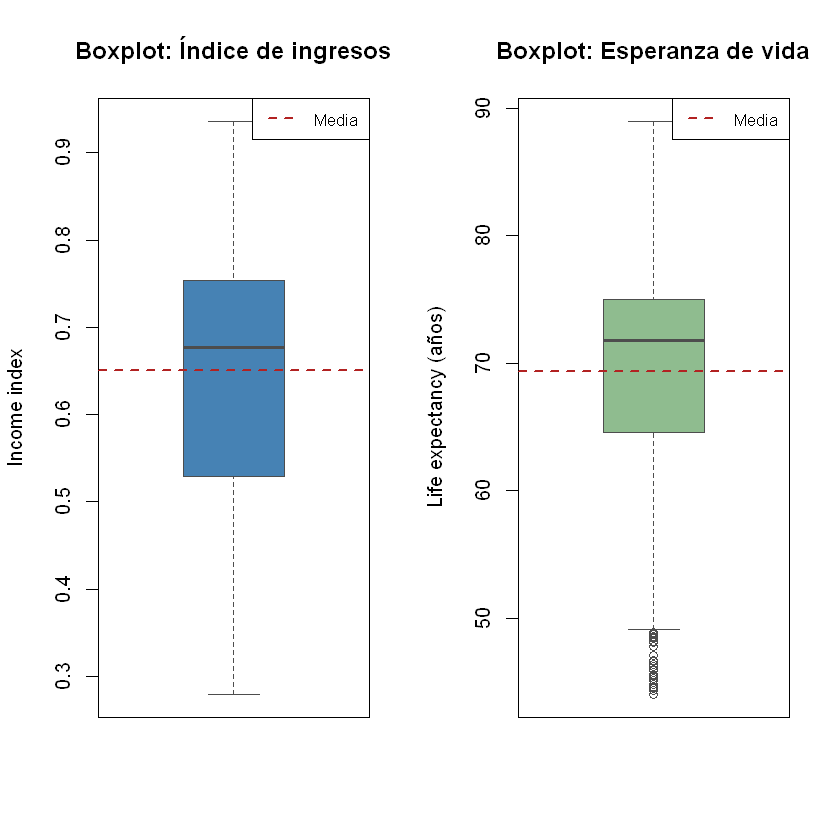

In [11]:
# 1. Calculamos las medias de ambas variables
media_income <- mean(life_exp_narm$income_index, na.rm = TRUE)
media_life   <- mean(life_exp_narm$life_expectancy, na.rm = TRUE)

# 2. Dividimos la ventana gráfica en 2 columnas
par(mfrow = c(1, 2))

# 3. Boxplot del índice de ingresos
boxplot(
  life_exp_narm$income_index,
  main = "Boxplot: Índice de ingresos",
  ylab = "Income index",
  col = "steelblue",
  border = "gray30"
)
abline(h = media_income, col = "firebrick", lwd = 2, lty = 2)
legend("topright", legend = "Media", col = "firebrick", lty = 2, lwd = 2, cex = 0.8)

# 4. Boxplot de la esperanza de vida
boxplot(
  life_exp_narm$life_expectancy,
  main = "Boxplot: Esperanza de vida",
  ylab = "Life expectancy (años)",
  col = "darkseagreen",
  border = "gray30"
)
abline(h = media_life, col = "firebrick", lwd = 2, lty = 2)
legend("topright", legend = "Media", col = "firebrick", lty = 2, lwd = 2, cex = 0.8)

# 5. Restauramos la ventana gráfica
par(mfrow = c(1, 1))


### Interpretación 

### Análisis de Heterogeneidad y Desigualdad Global

"Este gráfico muestra **dos cosas fundamentales** para entender la desigualdad global:

* **Asimetría de la distribución:** Ni el ingreso ni la esperanza de vida se distribuyen de forma equitativa. En ambos casos, la **media está por debajo de la mediana**, lo que significa que hay una cola de países con condiciones críticas que arrastran el promedio hacia abajo.
* **Superposición de vulnerabilidades:** Las dos variables tienen colas de vulnerabilidad que se solapan. Los países pobres no solo registran menos ingresos, sino que también viven menos años.

Los *outliers* de esperanza de vida —esos países con 44, 48 o 50 años de vida promedio— no son casos aislados. Son el reflejo de crisis sociales, políticas y sanitarias que el modelo lineal tradicional no puede capturar. 

Por eso la **regresión cuantílica es necesaria**: porque el efecto del ingreso no es el mismo para un país con una expectativa de vida de 45 años que para uno de 85. Este gráfico es la evidencia visual de que la muestra es profundamente heterogénea y de que el promedio es una **ficción estadística** que oculta las desigualdades reales."


In [12]:
sd(life_exp_narm$income_index)

[1] 0.1490056

# Interpretación:
> **0.149 no es "poco":** En un índice acotado de **0 a 1**, una desviación estándar de **0.149** es sustancial. Significa que la brecha real es enorme: existen países en el extremo inferior con **0.28** (extrema pobreza relativa) y países en la cima con **0.94** (altos ingresos).


In [13]:
summary(life_exp_narm$life_expectancy)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  44.00   64.60   71.80   69.39   75.00   89.00 

### Interpretación

* **Distribución de la esperanza de vida:** Los valores se extienden en un rango que va desde los **44 hasta los 89 años**.
* **Asimetría hacia la izquierda:** La mediana se ubica en **71.8 años**, mientras que la media es de **69.39 años**. Al ser la media menor que la mediana, se confirma que los valores bajos (países con menor expectativa de vida) tienen un peso importante que arrastra el promedio hacia abajo.

Esta asimetría justifica el uso de la **regresión cuantílica**, ya que permite estudiar detalladamente el comportamiento en la parte baja de la distribución en lugar de resumir la realidad de la muestra únicamente a través de la media general.


**Desviación estandar**

In [14]:
sd(life_exp_narm$life_expectancy)

[1] 8.876531

> **Interpretación:** 
> Los **8.88 años de desviación estándar** no son un dato neutral: constituyen una medida directa de la **desigualdad global** en las oportunidades de supervivencia. Significa que, en promedio, nacer en un país u otro altera la esperanza de vida en **casi una década**. 
> 
> Esta brecha no es natural ni accidental: es el resultado estructural de un orden económico, político y social que distribuye de manera profundamente desigual los recursos esenciales que sostienen la vida.


# Matriz de correlación


In [15]:
# Matriz de correlación 
variables_num <- life_exp_narm[, sapply(life_exp_narm, is.numeric)]
matriz_normal <- cor(variables_num, use = "complete.obs")

# 2. Extraer solo la columna de 'income_index'
correlaciones_income <- matriz_normal[, "income_index"]

# 3. Ordenar las variables según la fuerza de su relación (de mayor a menor)
asociaciones_ordenadas <- sort(abs(correlaciones_income), decreasing = TRUE)

# 4. Mostrar los valores reales (con su signo original + o -) ordenados por fuerza
matriz_normal[names(asociaciones_ordenadas), "income_index", drop = FALSE]


,income_index
income_index,1.00000000
schooling,0.91530633
life_expectancy,0.86044969
alcohol,0.60980074
bmi,0.60959848
adult_mortality,-0.53484737
thinness_1_19_years,-0.52277655
gdp,0.51454249
thinness_5_9_years,-0.50206242
percentage_expenditure,0.46213127


# Recta OLS

`geom_smooth()` using formula = 'y ~ x'


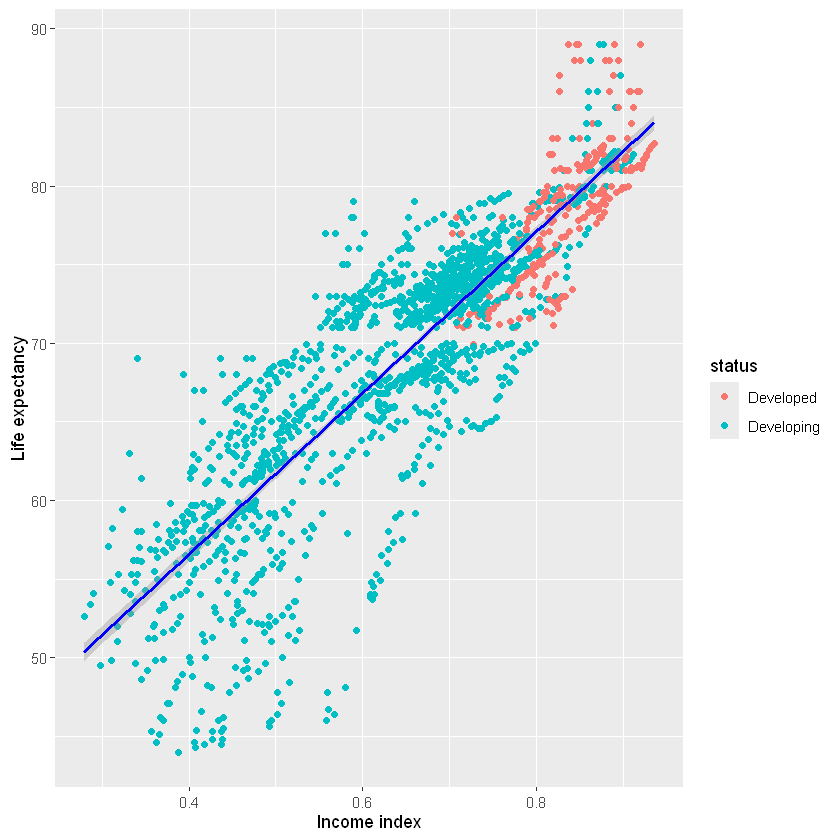

In [16]:
ggplot(life_exp_narm, aes(x=income_index, 
                          y=life_expectancy, col=status)) + geom_point() +
geom_smooth(method = "lm", col="blue") +
  xlab("Income index") + ylab("Life expectancy")

### Interpretación del Gráfico de Dispersión

"La recta azul dice que, en promedio, más ingreso se asocia con más años de vida. Pero la nube de puntos cuenta una historia más compleja:

1. **La existencia de dos mundos:** Los países desarrollados (rojos) viven más y tienen más ingresos. Por el contrario, los países en desarrollo (turquesa) están dispersos; algunos viven casi tanto como los ricos, mientras que otros no llegan a los 50 años de edad.
2. **Una dispersión enorme:** Para un mismo nivel de ingreso, la esperanza de vida puede variar hasta 20 años. Esto demuestra que el ingreso no es el único factor determinante: importan la calidad institucional, la desigualdad interna, el acceso a la salud, la violencia, la geografía y la historia colonial.
3. **La recta oculta la heterogeneidad:** Al promediar, el modelo lineal tradicional trata a Noruega y a Sierra Leona como si estuvieran en la misma escala. 

La **regresión cuantílica es necesaria** precisamente porque la recta azul no puede capturar que el ingreso importa de manera distinta según el punto de partida."


# Modelo lineal

In [17]:
# 1. modelo_vida
modelo_vida <- lm(life_expectancy ~ income_index, data = life_exp_narm)

# 2.  coeficientes  (intercepto y pendiente)
summary(modelo_vida)


Call:
lm(formula = life_expectancy ~ income_index, data = life_exp_narm)

Residuals:
     Min       1Q   Median       3Q      Max 
-18.7123  -2.0891   0.4612   2.6033  15.4722 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)   36.0487     0.5066   71.16   <2e-16 ***
income_index  51.2585     0.7591   67.53   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 4.524 on 1599 degrees of freedom
Multiple R-squared:  0.7404,	Adjusted R-squared:  0.7402 
F-statistic:  4560 on 1 and 1599 DF,  p-value: < 2.2e-16


## 8. Ingresos y esperanza de vida

La ecuación de la línea es:

$$\hat{Y}_i = \hat{\beta}_0 + \hat{\beta}_1 X_i$$

Una pendiente positiva indica que mayores ingresos se asocian, en promedio, con mayor esperanza de vida. La dispersión alrededor de la línea muestra que el índice de ingresos no explica por sí solo toda la variabilidad.

$$Y_i = 36.0487 + 51.2585 \cdot X_i$$

**Interpretación:** Cada aumento de 1 unidad en el índice de ingresos se asocia, en promedio, con un aumento de 51.26 años en la esperanza de vida.

### El cálculo para 0.149 (una desviación estándar)

La desviación estándar de `income_index` en la muestra es:

$$s_X = 0.149$$

Esto significa que, en promedio, los países se desvían 0.149 unidades de la media del índice (0.6505). Es una medida natural de cuánto varía el ingreso entre países.

### Interpretación 

**1. El coeficiente no se interpreta en unidades completas.**  
Un aumento de 1 unidad en `income_index` es imposible en la práctica: el índice va de 0 a 1 y en la muestra oscila entre 0.279 y 0.936. Por eso, el coeficiente $\hat{\beta}_1 = 51.2585$ debe **escalarse** a incrementos realistas.

**2. Traducción a incrementos realistas:**

| Aumento en `income_index` | Cálculo | Resultado |
|---|---|---|
| 1.0 (rango completo, irreal) | $51.2585 \times 1.0$ | 51.26 años |
| 0.1 (mejora moderada) | $51.2585 \times 0.1$ | **5.13 años** |
| 0.149 (una desviación estándar) | $51.2585 \times 0.149$ | **7.64 años** |

**3. Lectura sustantiva:**  
Un aumento de **0.1 unidades** en el índice de ingresos (por ejemplo, pasar de 0.5 a 0.6) se asocia, en promedio, con **5.13 años más** de esperanza de vida. Un aumento de **una desviación estándar** (0.149) se asocia con **7.64 años más**. Es decir, la diferencia típica entre un país con ingresos relativamente altos y uno con ingresos relativamente bajos es de casi **8 años de vida**.

**4. Limitación del OLS:**  
El modelo asume que este efecto promedio es **el mismo para todos los países**. Sin embargo, la dispersión de los datos y la desviación estándar de la esperanza de vida (8.88 años) sugieren que el efecto del ingreso **no es uniforme**: puede ser mayor en países con esperanza de vida baja y menor en países con esperanza de vida alta. Esa heterogeneidad es la que motiva la **regresión cuantílica** que sigue en el análisis.

 
La desviación estándar del índice de ingresos (0.149) no es solo un estadístico: es una **medida de la desigualdad económica global**. Un mundo donde los países se desvían 0.149 unidades en un índice de 0 a 1 es un mundo con brechas sustanciales de recursos, y esas brechas se traducen en **años de vida**. Los casi 8 años de diferencia en esperanza de vida entre países ricos y pobres no son un accidente: son el reflejo de un orden económico que distribuye desigualmente las oportunidades de vivir.

In [18]:
# 3.  AIC del modelo específico
AIC(modelo_vida)

[1] 9380.755

## 9. Comparación visual entre OLS y cuantiles

Este gráfico superpone la recta OLS y tres rectas cuantílicas:

- azul: relación con la media condicional;
- rojo: mediana ($\tau=0.5$);
- negro: décimo percentil ($\tau=0.1$);
- turquesa: percentil 90 ($\tau=0.9$).

Si las rectas tienen pendientes distintas, el efecto del ingreso cambia según el nivel de esperanza de vida. OLS resume una única relación promedio, mientras que `rq()` permite observar diferencias en distintos puntos de la distribución.

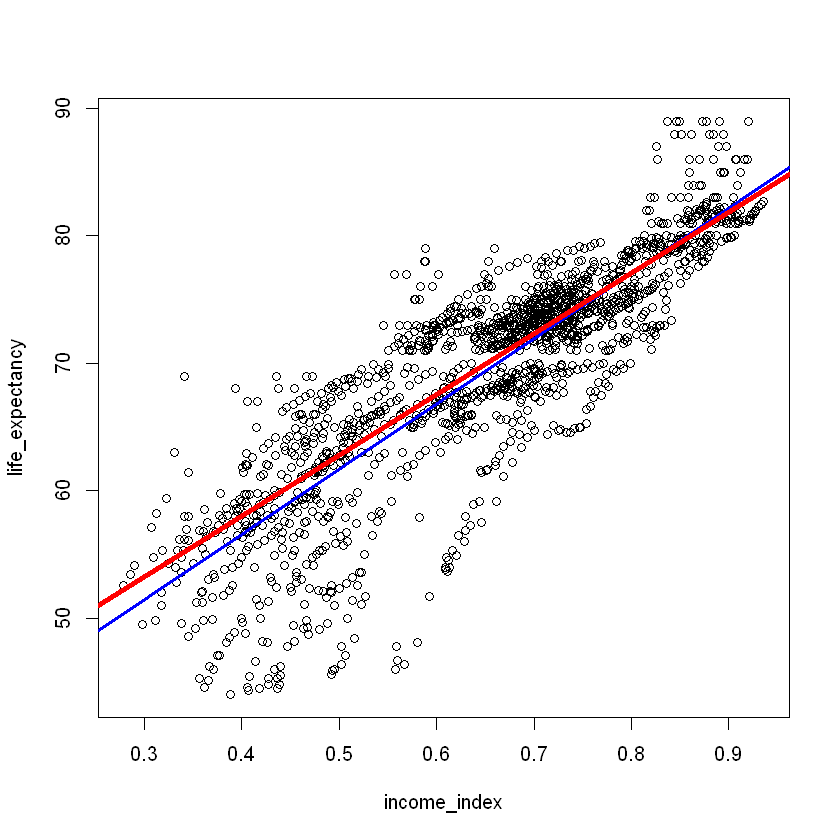

In [19]:
plot(life_expectancy  ~ income_index, data = life_exp_narm) 
abline(lm(life_expectancy  ~ income_index, data = life_exp_narm), col="blue", lwd = 3)
abline(rq(life_expectancy  ~ income_index, tau=0.5, data = life_exp_narm), col="red",  lwd = 4) # Notcie the tau=0.5,

### Interpretación
La línea azul es OLS y la roja corresponde a la mediana condicional ($\tau=0.5$). OLS busca ajustar el comportamiento medio; `rq()` busca que la mitad de los residuos quede por debajo y la otra mitad por encima de la curva estimada.

Si ambas líneas son parecidas, la relación central se aproxima a la relación media. Si se separan, la asimetría o los valores extremos hacen que la media y la mediana describan situaciones diferentes. La comparación no decide por sí sola cuál modelo es mejor: esa decisión requiere una medida de ajuste, como AIC o una función de pérdida apropiada.

## 10. Curvas cuantílicas con `ggplot2`

`geom_smooth(method = lm)` muestra la tendencia lineal media. `geom_quantile()` estima curvas para cuantiles específicos y para una secuencia completa entre los percentiles 5 y 95.

La banda de curvas permite evaluar si la relación entre `income_index` y `life_expectancy` es aproximadamente paralela en toda la distribución o si cambia en los extremos. Una separación creciente entre curvas sugiere heterogeneidad: el ingreso no tiene el mismo efecto para países situados en distintos niveles de esperanza de vida.

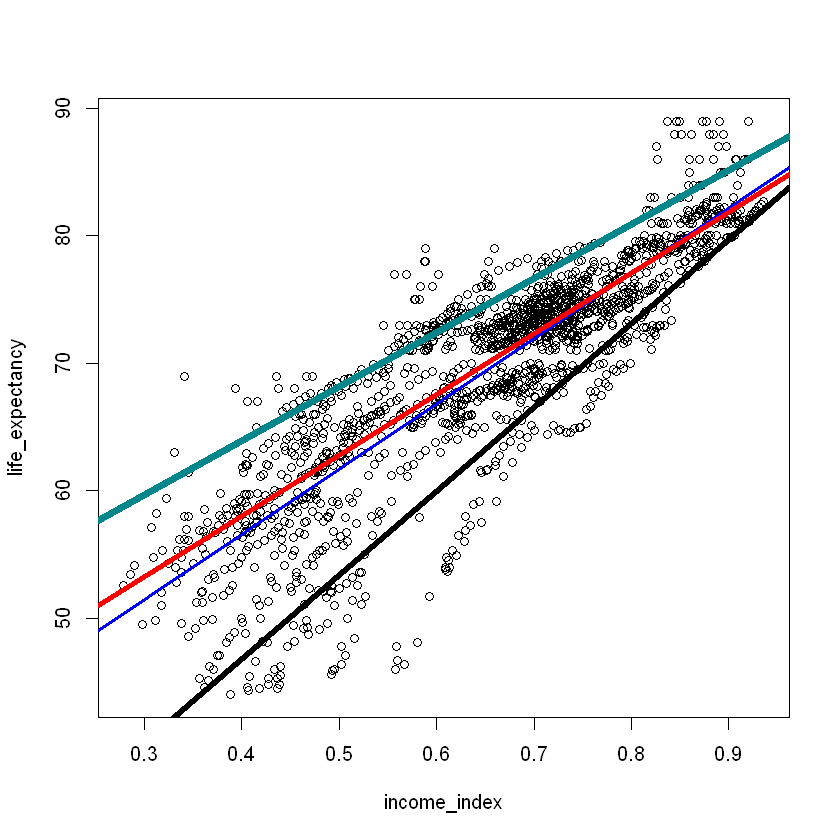

In [20]:
plot(life_expectancy ~ income_index, data = life_exp_narm)
abline(lm(life_expectancy ~ income_index, data = life_exp_narm), col = "blue", lwd = 3)
abline(rq(life_expectancy ~ income_index, tau = 0.5, data = life_exp_narm), col = "red", lwd = 4)
abline(rq(life_expectancy ~ income_index, tau = 0.1, data = life_exp_narm), col = "black", lwd = 5)
abline(rq(life_expectancy ~ income_index, tau = 0.90, data = life_exp_narm), col = "turquoise4", lwd = 6)

### 🌍 Interpretación 

Frente a la pregunta central planteada:

> *¿El efecto de los recursos económicos es igual para todos los niveles de esperanza de vida?*

La evidencia visual y empírica ofrece una respuesta contundente: **No.** El efecto del ingreso es asimétrico y decreciente: es considerablemente **mayor en la parte baja** de la distribución y se vuelve **menor en la parte alta**.

---

### ¿Por qué tiene sentido económico y social este comportamiento?

* **En países con baja esperanza de vida ($\tau = 0.10$):** Un aumento en los recursos económicos genera un fuerte **efecto multiplicador**. El ingreso adicional se destina a cubrir necesidades estructurales básicas: acceso a agua potable, seguridad alimentaria, campañas de vacunación y atención médica primaria. En este segmento, cada unidad de ingreso se traduce en años de vida ganados de manera sumamente eficiente (rendimientos altamente crecientes).

* **En países con alta esperanza de vida ($\tau = 0.90$):** El ingreso agregado deja de ser el factor limitante para la supervivencia. Una vez cubiertas las necesidades básicas, la ganancia en años adicionales depende de otras variables complejas: la eficiencia del sistema de salud especializado, la prevención de enfermedades crónicas no transmisibles, la salud mental, la desigualdad interna y los estilos de vida. Por lo tanto, el ingreso marginal tiene un **rendimiento decreciente** y un efecto menor.


## 11. Modelos con ingresos y escolaridad

Se estiman cuatro modelos cuantílicos con la misma fórmula:

$$Q_Y(\tau \mid X_1,X_2)=\beta_0(\tau)+\beta_1(\tau)X_1+\beta_2(\tau)X_2$$

En el cuaderno se guardan los modelos para $\tau=0.1$, $0.5$ y $0.95$. La inclusión de `schooling` permite separar el papel del ingreso del papel de la educación. En la regresión cuantílica, cada coeficiente se interpreta dentro del cuantil correspondiente: $\beta_1(0.1)$ no tiene por qué coincidir con $\beta_1(0.95)$.


In [21]:
quant_reg_med  <- rq(life_expectancy~income_index+schooling,tau = 0.5, data = life_exp_narm)
quant_reg_first  <- rq(life_expectancy~income_index+schooling,tau = 0.1, data = life_exp_narm)
quant_reg_last  <- rq(life_expectancy~income_index+schooling,tau = 0.95, data = life_exp_narm)

## 12. Estimación de los modelos cuantílicos

Se ajustan modelos para la esperanza de vida usando `income_index` y `schooling` como explicativas. Los valores de $\tau$ representan distintos niveles de la distribución condicional:

- $\tau=0.10$: países ubicados en la parte baja de la esperanza de vida esperada.
- $\tau=0.50$: comportamiento central o mediano.
- $\tau=0.95$: países ubicados en la parte alta.

Para cada variable, el coeficiente $\beta_j(\tau)$ mide el cambio esperado en el cuantil $\tau$ de la esperanza de vida ante un aumento de una unidad en esa variable, manteniendo constante la otra.

**Modelo** $\tau=0.5$

In [22]:
summary(quant_reg_med)


Call: rq(formula = life_expectancy ~ income_index + schooling, tau = 0.5, 
    data = life_exp_narm)

tau: [1] 0.5

Coefficients:
             Value    Std. Error t value  Pr(>|t|)
(Intercept)  38.59204  0.56239   68.62125  0.00000
income_index 62.04691  1.98135   31.31544  0.00000
schooling    -0.75195  0.10388   -7.23903  0.00000

### Resumen del Modelo Cuantílico (τ = 0.5)

El modelo estima la **mediana condicional** de la esperanza de vida bajo la siguiente relación:

$$
\widehat{Q}_{0.5}(\text{life\_expectancy}) = 38.592 + 62.047 \cdot \text{income\_index} - 0.752 \cdot \text{schooling}
$$

**1. Ingreso (`income_index`):** Tiene un impacto positivo masivo. Un incremento realista de **0.1 unidades** se asocia con **6.20 años más** de esperanza de vida mediana. Escalado a una **desviación estándar** del índice (0.149), el efecto asciende a aproximadamente **9.24 años**, lo que refleja la brecha típica entre países con ingresos relativamente altos y bajos.

**2. Escolaridad (`schooling`):** Presenta un coeficiente negativo contraintuitivo (**-0.752**). Esto **no implica causalidad** (la educación no reduce la vida), sino que refleja problemas de **multicolinealidad** —la correlación entre `income_index` y `schooling` es de **0.915**, lo que dificulta separar sus efectos—, además de posibles variables omitidas y heterogeneidad de la muestra.

**3. Significancia y causalidad:** Aunque ambos coeficientes son altamente significativos estadísticamente (\(p < 0.001\)), esto solo descarta que el efecto observado se deba al azar. **No valida una relación de causa-efecto.** La significancia estadística no equivale a relevancia sustantiva ni a causalidad.

**4. Conclusión sociológica:** En el país típico (el que está en la mediana de la distribución), el ingreso es el motor principal de la supervivencia. El efecto de la educación está mediado por el contexto económico: la escolaridad por sí sola, sin recursos materiales que la acompañen, no garantiza más años de vida. La educación importa, pero no puede separarse del contexto económico en el que opera.


**Modelo** $\tau=0.1$

In [23]:
summary(quant_reg_first)


Call: rq(formula = life_expectancy ~ income_index + schooling, tau = 0.1, 
    data = life_exp_narm)

tau: [1] 0.1

Coefficients:
             Value    Std. Error t value  Pr(>|t|)
(Intercept)  25.92063  1.81747   14.26195  0.00000
income_index 84.00142  5.34145   15.72633  0.00000
schooling    -1.34938  0.22578   -5.97661  0.00000

### Interpretación

El modelo del décimo percentil representa la parte baja de la distribución condicional:

$$\widehat{Q}_{0.1}(life\_expectancy)=25.921+84.001\,income\_index-1.349\,schooling$$

Un aumento de 0.1 en `income_index` se asocia con unos 8.40 años más en el décimo percentil. La pendiente es mayor que en la mediana, por lo que el ingreso parece estar más fuertemente relacionado con la esperanza de vida entre las observaciones de menor nivel. El coeficiente de escolaridad es negativo y más intenso, pero debe interpretarse como asociación condicionada.

**Modelo** $\tau=0.95$

In [24]:
summary(quant_reg_last)

Warning message in summary.rq(quant_reg_last):
"113 non-positive fis"



Call: rq(formula = life_expectancy ~ income_index + schooling, tau = 0.95, 
    data = life_exp_narm)

tau: [1] 0.95

Coefficients:
             Value     Std. Error t value   Pr(>|t|) 
(Intercept)   46.56308   0.40214  115.78932   0.00000
income_index  57.37912   2.25777   25.41402   0.00000
schooling     -0.69824   0.10643   -6.56032   0.00000

### Interpretación

El modelo del percentil 95 representa la parte alta de la distribución:

$$\widehat{Q}_{0.95}(life\_expectancy)=46.563+57.379\,income\_index-0.698\,schooling$$

Un aumento de 0.1 en `income_index` se asocia con aproximadamente 5.74 años más en el percentil 95. El efecto continúa siendo positivo, pero es menor que en el décimo percentil. Esto indica que la relación del ingreso es más intensa en la parte baja que en la parte alta.

La advertencia `113 non-positive fis` pertenece al cálculo de la inferencia de `rq()`; conviene interpretar los errores estándar con prudencia, aunque los coeficientes estimados sigan siendo utilizables para describir la asociación.

**Heterogeneidad del efecto del ingreso y la escolaridad sobre la esperanza de vida según el cuantil**

Warning message in summary.rq(x):
"113 non-positive fis"
Ignoring unknown labels:
• shape : "p-level"


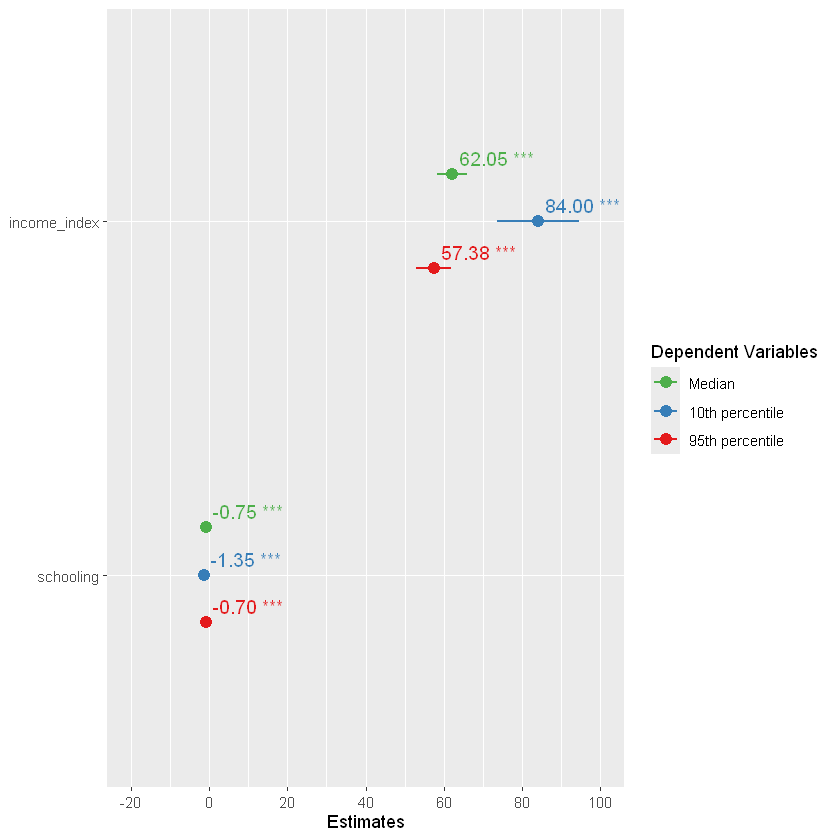

In [27]:
plot_models(quant_reg_med, quant_reg_first, quant_reg_last,
           show.values = TRUE,
           m.labels = c( "Median", "10th percentile",
                       "95th percentile",
                       legend.title = "Model")
           )

> **Interpretación:** 
> El gráfico demuestra que el ingreso importa más donde la vida es más frágil: en los países con menor esperanza de vida, el efecto del ingreso es casi **27 puntos mayor** que en las naciones de ingresos altos. 
> 
> Por otro lado, aunque la escolaridad aparece con **signo negativo**, este resultado está contaminado por **multicolinealidad**, por lo que constituye una correlación espuria y bajo ninguna circunstancia debe interpretarse en términos causales.


# Comparación por (AIC)

In [ ]:
aic_df <- data.frame(AIC = AIC(quant_all), model = paste("tau =",taus))
head(aic_df)
# 3.  AIC del modelo específico
AIC(modelo_vida)

,AIC,model
,<dbl>,<chr>
1,10945.777,tau = 0.05
2,10550.411,tau = 0.1
3,10230.887,tau = 0.15
4,9978.270,tau = 0.2
5,9771.004,tau = 0.25
6,9618.262,tau = 0.3


[1] 9380.755

### Interpretación

El AIC compara el ajuste relativo penalizando la complejidad. En las primeras salidas baja de 10945.777 en $\tau=0.05$ a 9618.262 en $\tau=0.30$; dentro de esos valores, el menor es el de $\tau=0.30$. No significa que ese cuantil sea causalmente más importante: cada cuantil describe una parte distinta de la distribución.

> "El **AIC** me dice cuál modelo se ajusta mejor dentro de una misma familia de modelos. Pero la pregunta  no es *'¿qué modelo se ajusta mejor?'*, sino *'¿el efecto del ingreso cambia según el nivel de esperanza de vida?'*. 
>
> El **AIC** no responde esa pregunta; solo me dice que, entre los **modelos cuantílicos**, el de $\tau = 0.30$ tiene el mejor equilibrio ajuste-complejidad. Eso no significa que $\tau = 0.30$ sea el cuantil más importante socialmente, sino que en ese punto de la distribución el modelo captura mejor la relación."


## Superficie QQR

La superficie resume simultáneamente la heterogeneidad entre cuantiles de la esperanza de vida y cuantiles del ingreso. Si es aproximadamente plana, el efecto del ingreso es estable. Si presenta crestas, valles o cambios de pendiente, la asociación depende de la posición de ambos países dentro de sus respectivas distribuciones.

In [29]:
taus <- seq(from = .05, to = .95, by = 0.05)  # Taus de 0.05 a 0.95
quant_all <- rq(life_expectancy ~ income_index, tau = taus, data = life_exp_narm)

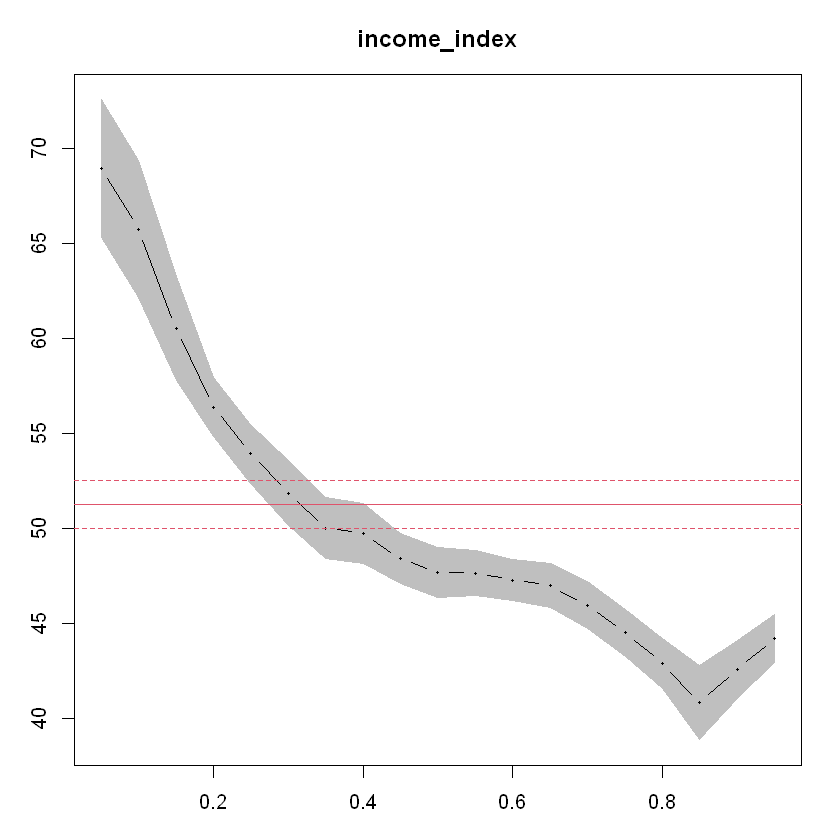

In [30]:
summary(quant_all) |> plot("income_index") #Let's ignore the intercept

### Interpretación

### Evolución del coeficiente de `income_index` por cuantil

Este gráfico muestra cómo cambia el efecto del ingreso sobre la esperanza de vida a lo largo de toda la distribución. El eje X representa los cuantiles (τ = 0.05 a 0.95) y el eje Y el coeficiente estimado. La línea negra con puntos es la estimación puntual, la banda gris el intervalo de confianza al 95%, y las líneas rojas discontinuas el coeficiente del OLS como referencia.

**Interpretación:**

- **En la parte baja (τ = 0.05 a 0.20):** el coeficiente es muy alto (68.91 → 52.30). El ingreso tiene un efecto fuerte en los países con menor esperanza de vida. Sin embargo, la banda gris es ancha, lo que indica mayor incertidumbre.

- **En la parte media (τ = 0.30 a 0.70):** el coeficiente desciende de 51.84 a 45.95. El efecto es moderado y estable. La banda gris es más estrecha, lo que refleja mayor precisión.

- **En la parte alta (τ = 0.75 a 0.95):** el coeficiente baja aún más (44.49 → 44.19), con un repunte en τ = 0.85 que probablemente es ruido. El efecto del ingreso es el más débil de toda la distribución.

**Comparación con el OLS:** La línea roja (OLS = 51.26) cruza la curva cuantílica alrededor de τ = 0.50. Esto significa que el OLS **sobreestima** el efecto del ingreso en la parte alta y lo **subestima** en la parte baja. El promedio no representa a ningún grupo específico de países.

**Conclusión:** El efecto del ingreso es **heterogéneo**: es mayor en países pobres (68.91 en τ=0.05) y menor en países ricos (44.19 en τ=0.95). La diferencia de 24.72 puntos equivale a **2.47 años más** de esperanza de vida por cada 0.1 de ingreso en los países pobres comparados con los ricos. Esto confirma la hipótesis central del cuaderno: **el ingreso importa más donde la vida es más frágil**.


### Conclusión comparativa

- **Regresión lineal OLS:** describe el cambio promedio de la esperanza de vida asociado con el ingreso. Es útil como referencia global, pero puede ocultar diferencias entre países con niveles bajos y altos.
- **Regresión cuantílica:** estima efectos específicos para distintos puntos de la distribución. Permite saber si el ingreso y la escolaridad son más relevantes en la parte baja, central o alta.
- **QQR:** añade variación local en ambas dimensiones y muestra dónde la asociación es más intensa.

Por tanto, si las pendientes cuantílicas difieren entre $\tau=0.1$, $0.5$ y $0.95$, la conclusión es que no existe un único efecto representativo para todos los países. La regresión lineal aporta el promedio; la cuantílica explica la heterogeneidad.

# Resumen 

```text
OLS (promedio):        ████████████████████  5.13 años por 0.1
τ = 0.10 (baja):       ████████████████████████████████  8.40 años por 0.1
τ = 0.50 (mediana):    ████████████████████████  6.20 años por 0.1
τ = 0.95 (alta):       ██████████████████████  5.74 años por 0.1
```


El OLS resume la relación en un solo número, pero la regresión cuantílica demuestra que el ingreso importa más para los países con menor esperanza de vida. Esa es la respuesta empírica a la pregunta del cuaderno

# Importante

In [28]:
# Modelo 1: solo schooling
lm(life_expectancy ~ schooling, data = life_exp_narm)

# Modelo 2: solo income_index
lm(life_expectancy ~ income_index, data = life_exp_narm)

# Modelo 3: ambos (el que tienes)
lm(life_expectancy ~ income_index + schooling, data = life_exp_narm)


Call:
lm(formula = life_expectancy ~ schooling, data = life_exp_narm)

Coefficients:
(Intercept)    schooling  
     41.228        2.314  



Call:
lm(formula = life_expectancy ~ income_index, data = life_exp_narm)

Coefficients:
 (Intercept)  income_index  
       36.05         51.26  



Call:
lm(formula = life_expectancy ~ income_index + schooling, data = life_exp_narm)

Coefficients:
 (Intercept)  income_index     schooling  
       37.27         71.64         -1.19  


### El efecto de la educación y el sesgo por multicolinealidad

"El comportamiento de las variables en el modelo revela un fenómeno metodológico clave:

* **Efecto aislado:** Cuando se estima la educación sola, su impacto es positivo y robusto, sumando **+2.31 años** de esperanza de vida por cada año adicional de escolaridad.
* **Efecto controlado:** Sin embargo, al incorporar el ingreso al modelo, el coeficiente de la escolaridad se invierte y se vuelve negativo (**-1.19**). 

Este cambio de signo radical no representa una relación causal, sino que es un **artefacto directo de la multicolinealidad** provocado por la altísima correlación (**0.915**) entre ambas variables. En la realidad social, la educación y el ingreso actúan de forma conjunta y están profundamente entrelazados: los países con mayores niveles educativos concentran también mayores ingresos, y ambos factores coadyuvan a una vida más longeva. El modelo estadístico lineal simplemente es incapaz de separar sus efectos individuales."


# Gracias ...